Simulations for advancement! 

Part 1) Simulations of Cold Started Horizontal Convection (no hills) with increasing Rayleigh number. 

In [8]:
using Oceananigans

In [3]:
using TopographicHorizontalConvection: HorizontalConvectionSimulation

In [5]:
simulation = HorizontalConvectionSimulation(Ra=1e7, h₀_frac=0.6, numhill = 1, Nx=535, Ny=1, Nz=67, b_init=-0.6, advection=true, architecture=CPU())

Simulation of NonhydrostaticModel{CPU, ImmersedBoundaryGrid}(time = 0 seconds, iteration = 0)
├── Next time step: 12.217 ms
├── Elapsed wall time: 0 seconds
├── Wall time per iteration: NaN days
├── Stop time: 52.705 minutes
├── Stop iteration : Inf
├── Wall time limit: Inf
├── Callbacks: OrderedDict with 6 entries:
│   ├── stop_time_exceeded => Callback of stop_time_exceeded on IterationInterval(1)
│   ├── stop_iteration_exceeded => Callback of stop_iteration_exceeded on IterationInterval(1)
│   ├── wall_time_limit_exceeded => Callback of wall_time_limit_exceeded on IterationInterval(1)
│   ├── nan_checker => Callback of NaNChecker for u on IterationInterval(100)
│   ├── wizard => Callback of TimeStepWizard(cfl=0.5, max_Δt=Inf, min_Δt=0.0) on IterationInterval(50)
│   └── progress => Callback of (::TopographicHorizontalConvection.var"#progress#9") on IterationInterval(10)
├── Output writers: OrderedDict with 6 entries:
│   ├── checkpointer => Checkpointer{TimeInterval, Vector{Symbol}}

In [1]:
using NCDatasets
using CairoMakie
using Printf
using Oceananigans.Fields
using Oceananigans.AbstractOperations: volume
using NaNStatistics

No hills simulations of horizontal convection:: Ra = 1e5 to 1e7. 

Below is an animation of Ra=1e5 -- laminar

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills1e5.mp4" type "video/mp4">
</video>

In [2]:
using TopographicHorizontalConvection:ε_analysis
using TopographicHorizontalConvection:plot_ε_normalized
using TopographicHorizontalConvection:plot_ε_avg

In [4]:
ds0_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra100000.0_coldstart_buoyancy.nc"));
ds0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra100000.0_coldstart_oceanostics.nc"));

we want to create a heatmap comparing simulation epsilon to theoretical epsilon at the equilibrium time. let's assume the equilibrium time is the last ten percent of the timeseries. 

In [6]:
ε_theory_0, ε_avg_0, ε_mean_0 = ε_analysis(ds0_o);
t_0 = ds0_o["time"][:];

In [9]:
ε_0 = ds0_o["ε"][4+1:end-4, :, 4+1:end-4, :];
time_0 = ds0_o["time"][:];
x = ds0_o["xC"][4+1:end-4];
z = ds0_o["zC"][4+1:end-4];

function plot_ε_equilibrium(ds)
    ε = ds["ε"][4+1:end-4, :, 4+1:end-4, :]
    Ra = ds.attrib["Ra"]
    time = ds["time"][:]
    x = ds["xC"][4+1:end-4]
    z = ds["zC"][4+1:end-4]
    equilibrium_start = round(Int, 0.7 * size(time, 1))
    time_eq_start = time[equilibrium_start]
    ε_eq = ε[:, 1, :, equilibrium_start]

    ε_theory = ε_analysis(ds)[1]

    fig = Figure()
    ax = Axis(fig[1, 1], aspect =8, xlabel="x", ylabel="z", title="Mechanical Energy Dissipation Rate Normalized of Ra = $Ra Simulation at Equilibrium Time")

    hm = heatmap!(ax, x, z, ε_eq, colormap=:viridis)
    Colorbar(fig[1, 2], hm)
    return fig
end


plot_ε_equilibrium (generic function with 1 method)

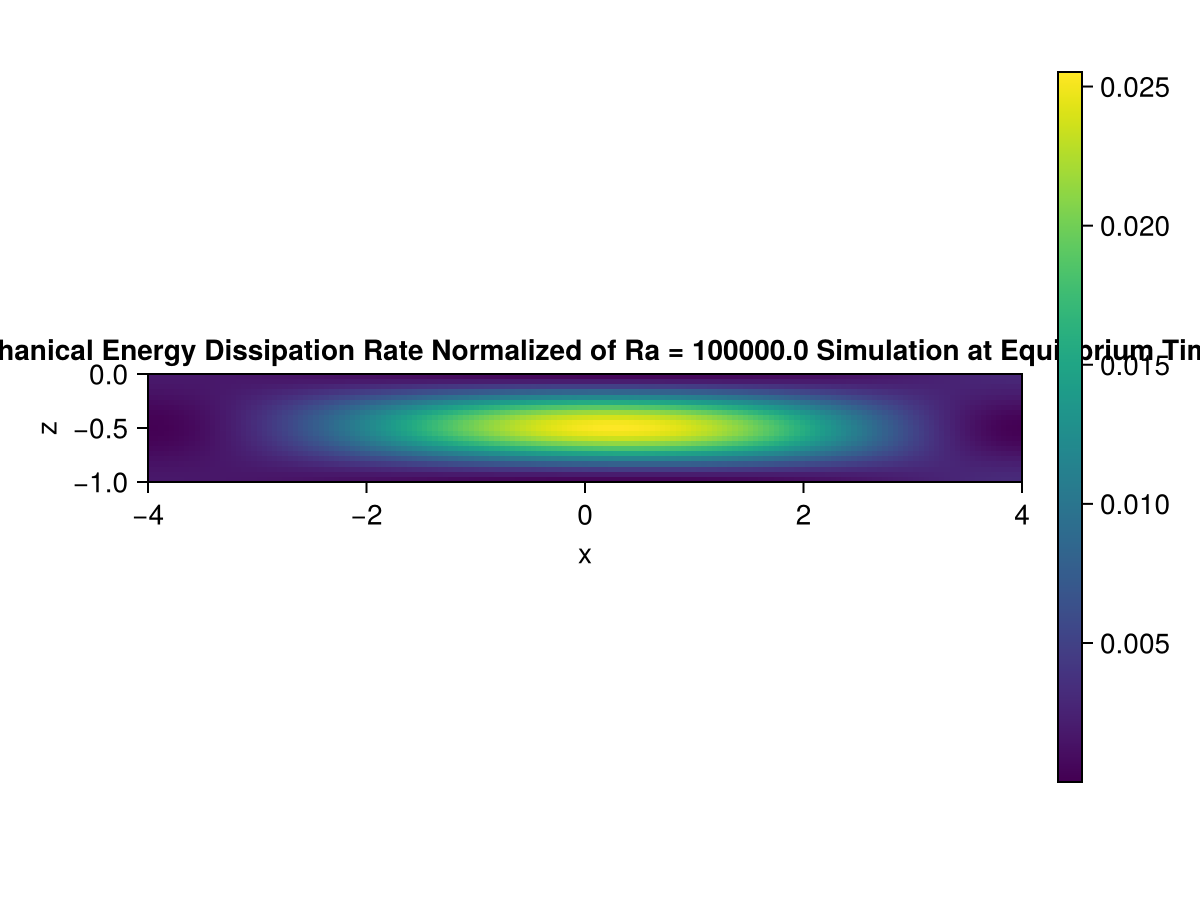

In [10]:
fig = plot_ε_equilibrium(ds0_o)

Next is the Ra=1e6 no hills simulation

In [5]:
ds1_b = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_buoyancy.nc"));
ds1_o = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_oceanostics.nc"));

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills1e6.mp4" type "video/mp4">
</video>

In [8]:
ε_theory_1, ε_avg_1, ε_mean_1 = ε_analysis(ds1_o);

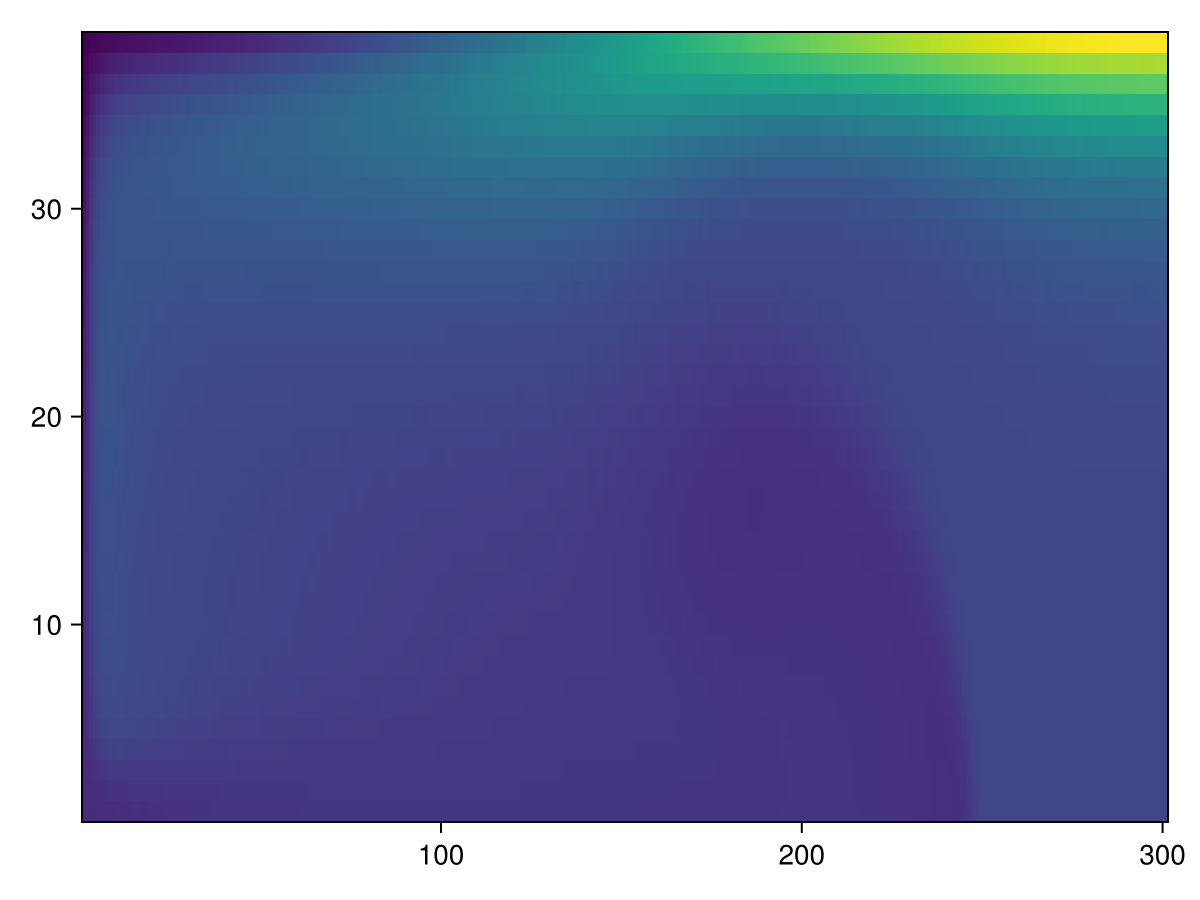

In [9]:
b = ds1_b["b"][4+1:end-4, :, 4+1:end-4, :];
time = ds1_b["time"][:];
size(time)

heatmap(b[:, 1, :, 10])

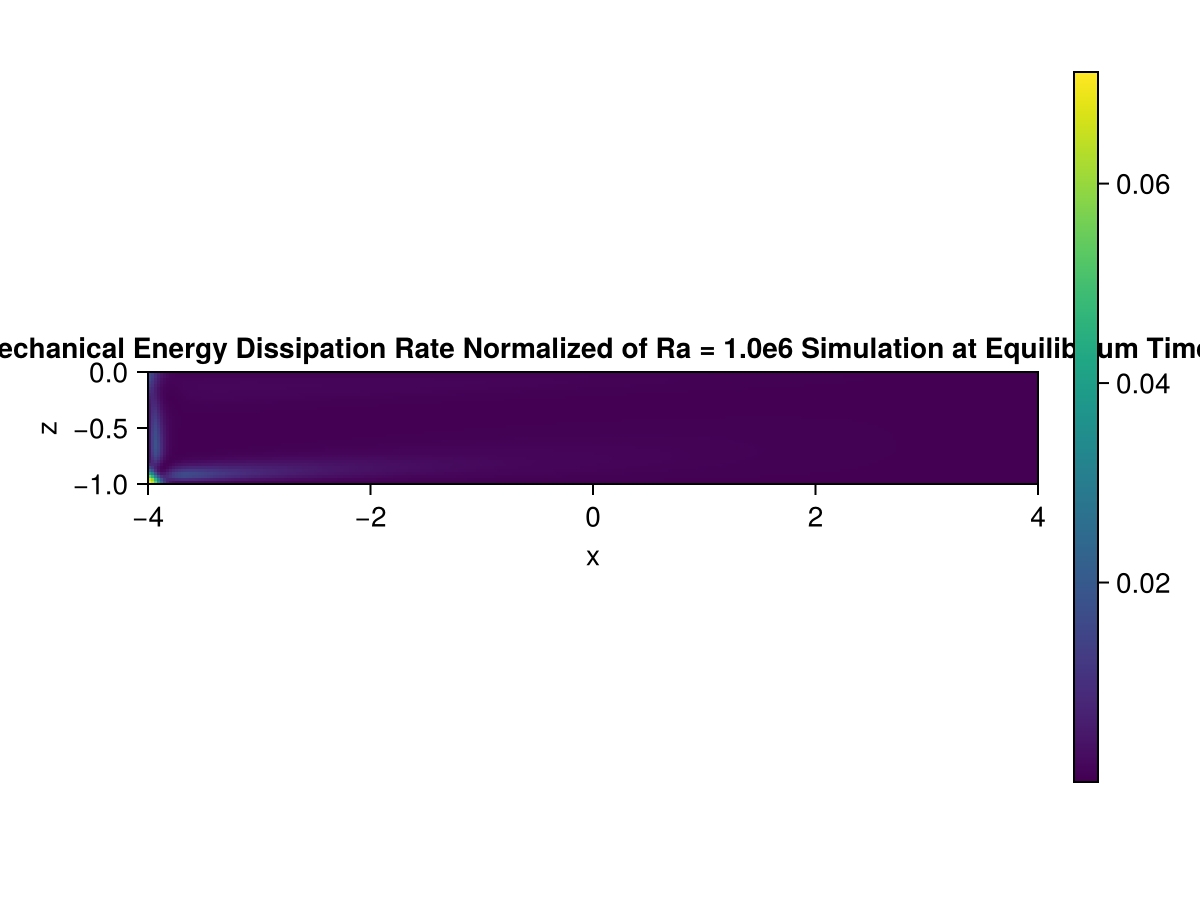

In [62]:
#repeat the equilibrium epsilon plot

fig2 = plot_ε_equilibrium(ds1_o)

In the second simulation we increase the Rayleigh number to 1e7
I didn't run this all the way to equilibrium $\tau_{eq} = \sqrt{1\times 10^{8}}$ because it took over 12 hours to just run up to $t=1830$ locally. 

In [20]:
ds3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra1.0e7_coldstart_oceanostics.nc"));
ds3_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra1.0e7_coldstart_buoyancy.nc"));

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills1e7.mp4" type "video/mp4">
</video>

In [12]:
ε_theory_2, ε_avg_2, ε_mean_2 = ε_analysis(ds2_o);

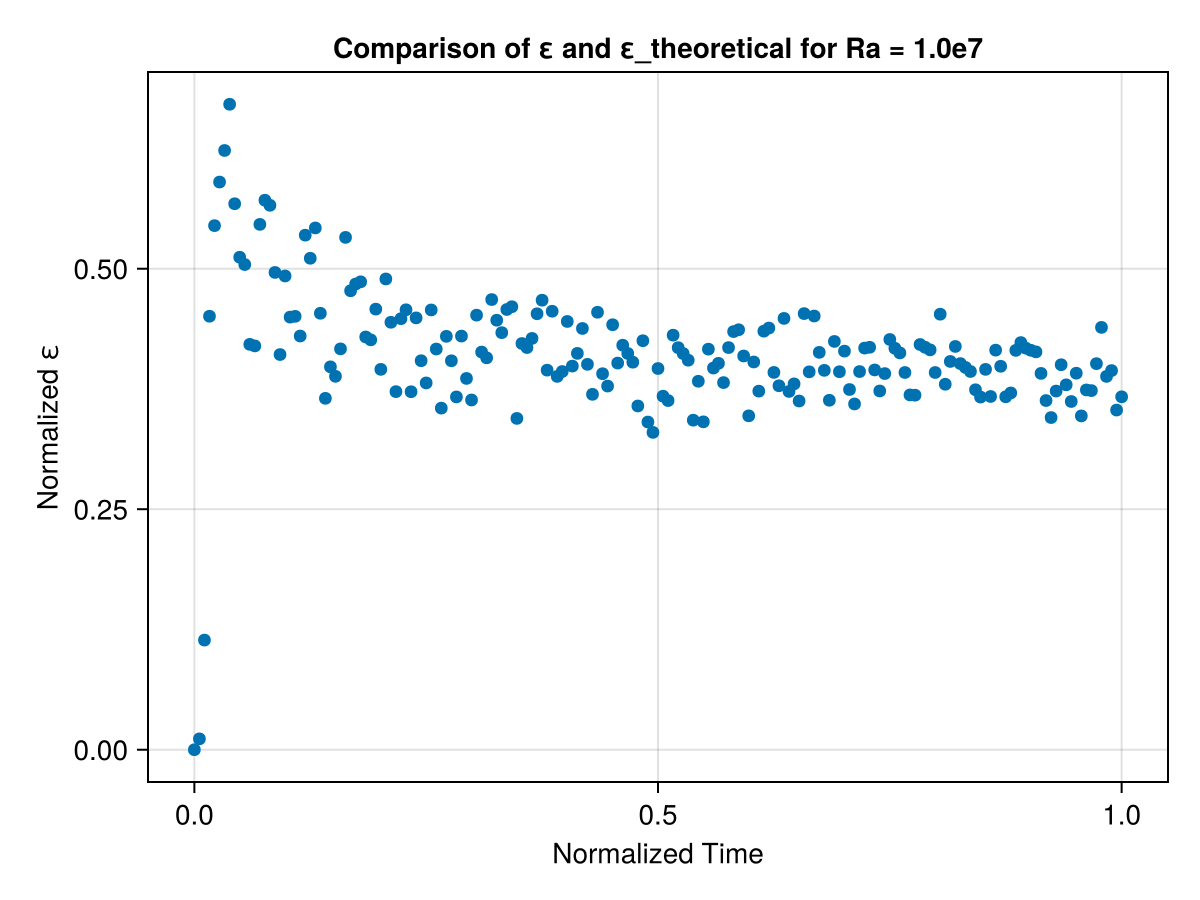

In [13]:
f2 = plot_ε_normalized(ds2_o)

In [94]:
#equilibrium ε plot

ε = ds["ε"][4+1:end-4, 1, 4+1:end-4, :]
Ra = ds.attrib["Ra"]
time = ds["time"][:]
print(size(time))
x = ds["xC"][4+1:end-4]
z = ds["zC"][4+1:end-4]
equilibrium_start = round(Int, 0.9 * size(time, 1))
print(equilibrium_start)
time_eq_start = time[equilibrium_start]
ε_eq = ε[:, :, equilibrium_start]

ε_theory = ε_analysis(ds)[1]



#fig3 = plot_ε_equilibrium(ds2_o)

(185,)166

0.0006324555320336759

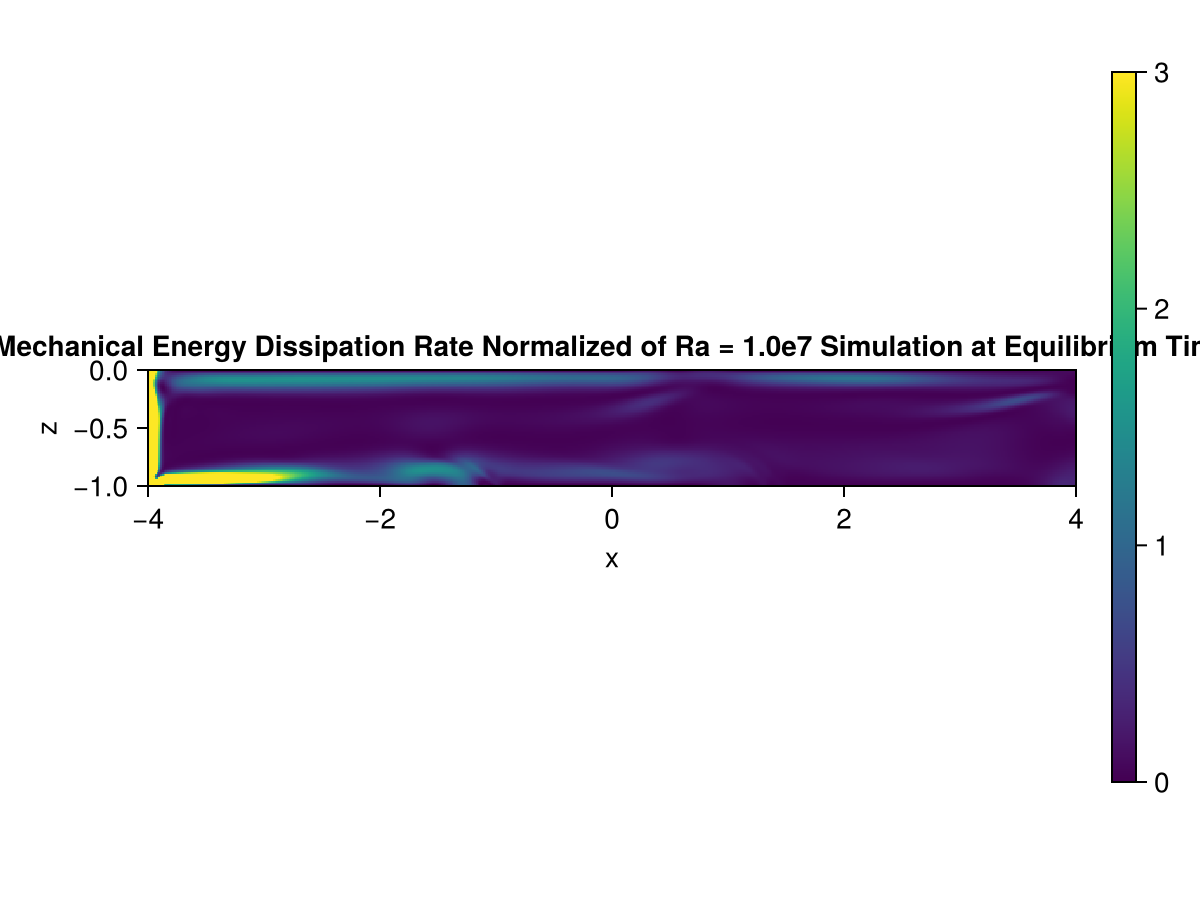

In [101]:
##
fig = Figure()
ax = Axis(fig[1, 1], aspect =8, xlabel="x", ylabel="z", title="Mechanical Energy Dissipation Rate Normalized of Ra = $Ra Simulation at Equilibrium Time")
hm = heatmap!(ax, x, z, ε_eq./ε_theory, colorrange = (0,3),colormap=:viridis)
Colorbar(fig[1, 2], hm)
fig

Below is the animation and similar analysis plot for Ra=5e6

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills5e6.mp4" type "video/mp4">
</video>

In [19]:
ds2_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra5.0e6_coldstart_buoyancy.nc"));
ds2_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra5.0e6_coldstart_oceanostics.nc"));

In [15]:
ε_theory_3, ε_avg_3, ε_mean_3 = ε_analysis(ds3_o);

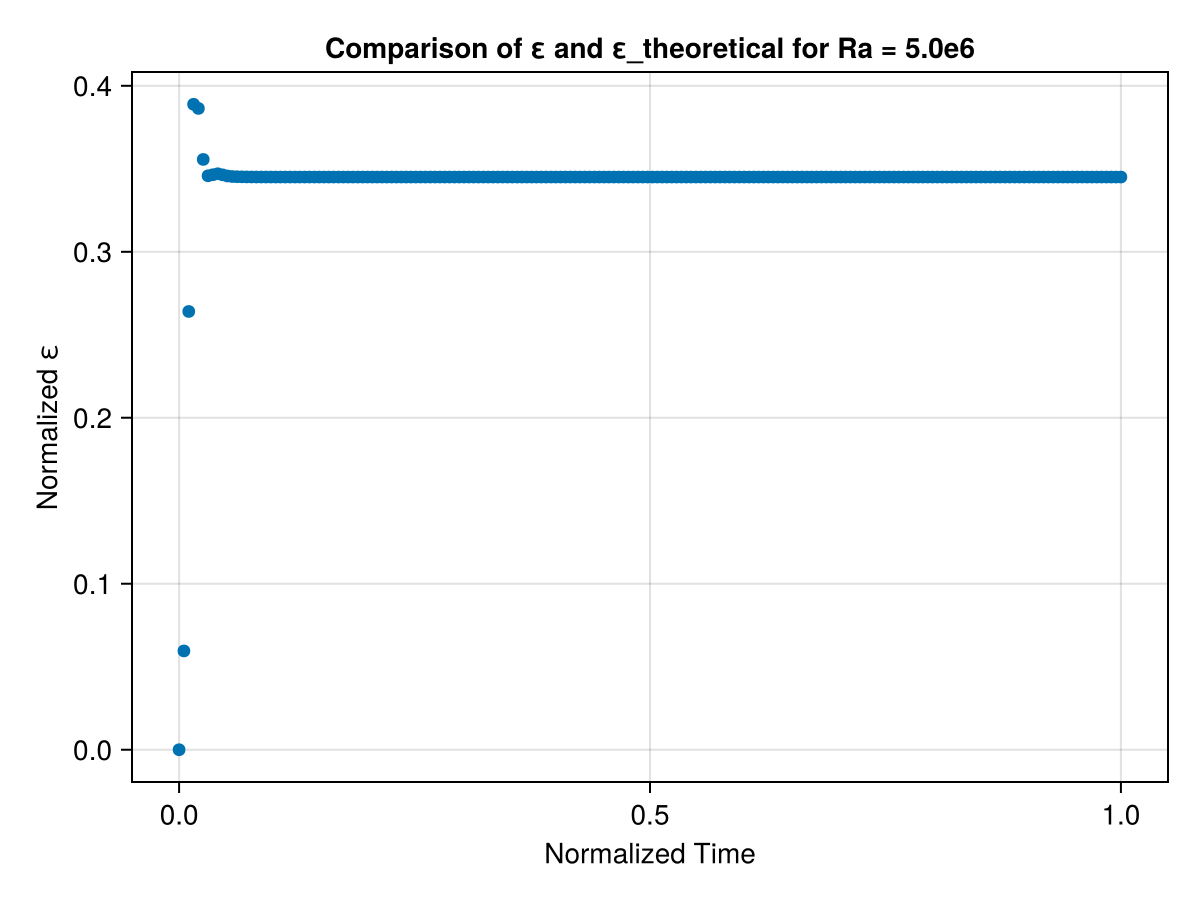

In [16]:
f3 = plot_ε_normalized(ds3_o)

f3

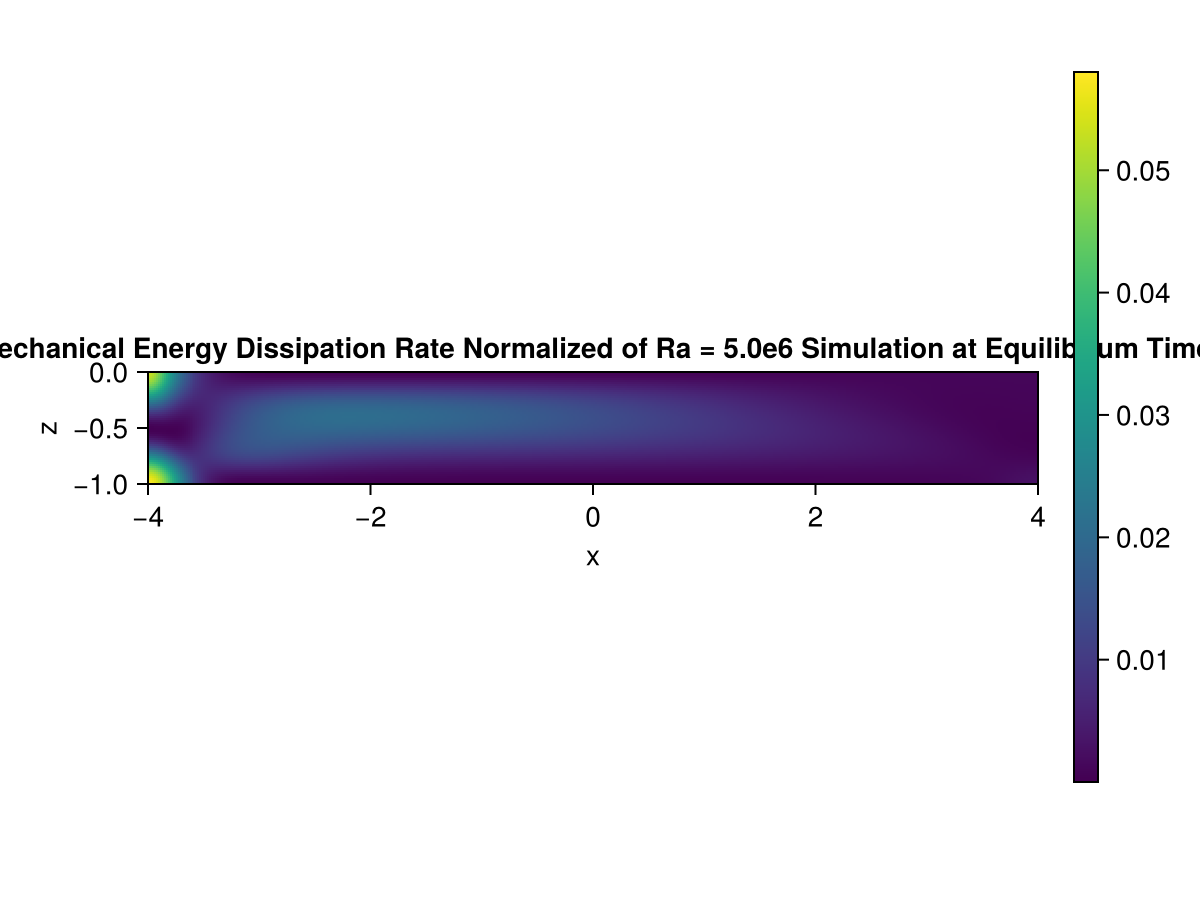

In [64]:
#equilibrium ε plot

fig4 = plot_ε_equilibrium(ds3_o)

NOW for the hills simulations

we start with Ra=1e5

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill1e5.mp4" type "video/mp4">
</video>

In [8]:
ds_h0_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_buoyancy.nc"));
ds_h0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_oceanostics.nc"));

In [33]:
x = ds["xC"][4+1:end-4]; Nx = length(x);
z = ds["zC"][4+1:end-4]; Nz = length(z);
time = ds["time"][:];
Δx = reshape(diff(ds["xF"])[4+1:end-4], Nx,1,1);
Δz = reshape(diff(ds["zF"])[4+1:end-4], 1,1,Nz);
ΔA = Δx; #flat in y -- 2 dimensional
ΔV = ΔA.*Δz;
var_array = zeros(size(time,1));
for n in 1:size(time, 1)
    var_t = ds["ε"][4+1:end-4, :, 4+1:end-4, n]
    wet = var_t.!=0.
    var_t[.!wet] .= NaN
    var_array[n] = nansum(
        var_t .*
        ΔV,
        dims=(1,2,3)
    )[1,1,1]
end

In [69]:
ε_t = ds["ε"][4+1:end-4, :, 4+1:end-4, 4];
wet = ε_t.!=0.

size(ΔV)

(169, 1, 21)

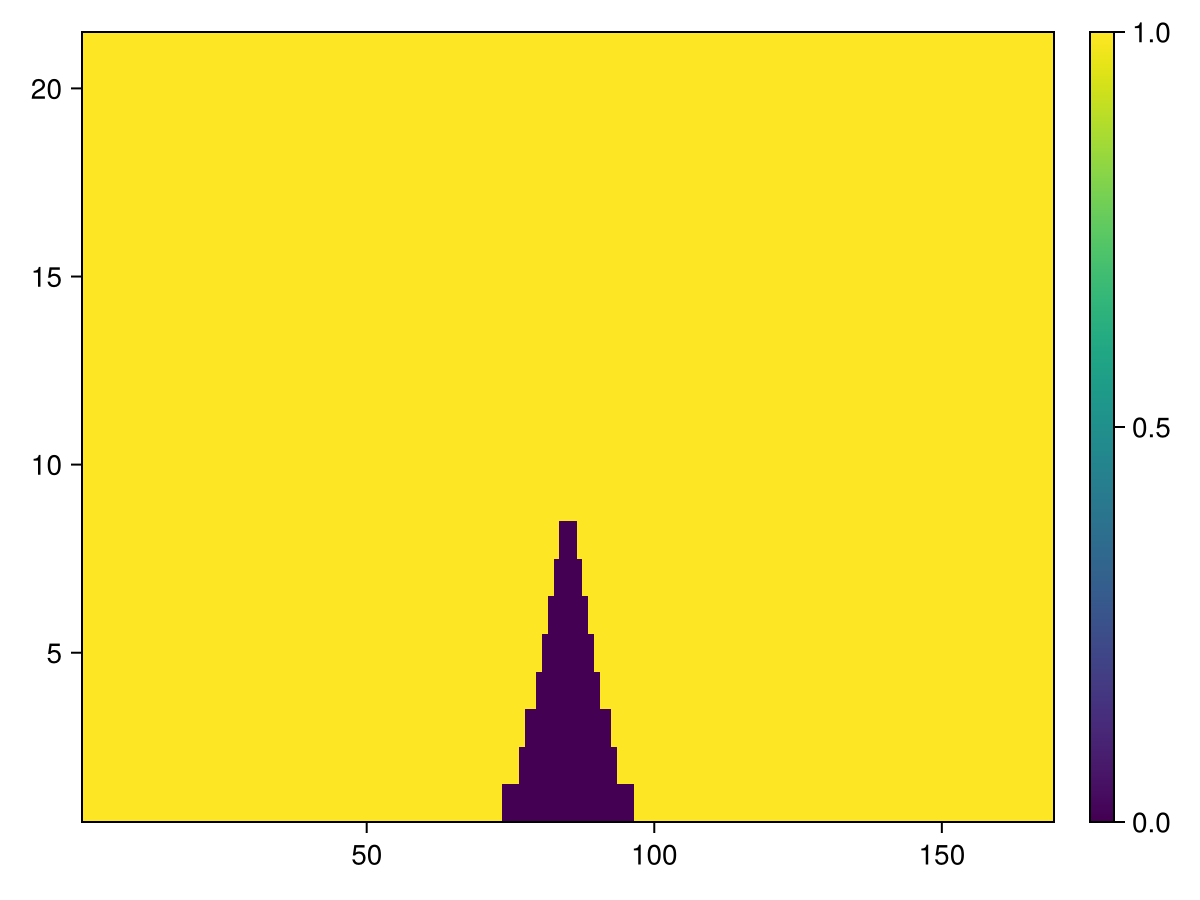

In [68]:
ff = Figure()
ax = Axis(ff[1, 1])
hm = heatmap!(ax, wet[:, 1, :])
Colorbar(ff[1, 2], hm)
ff

below is Ra=1e6 with one hill

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill1e6.mp4" type "video/mp4">
</video>

In [9]:
ds_h1_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_buoyancy.nc"));
ds_h1_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_oceanostics.nc"));


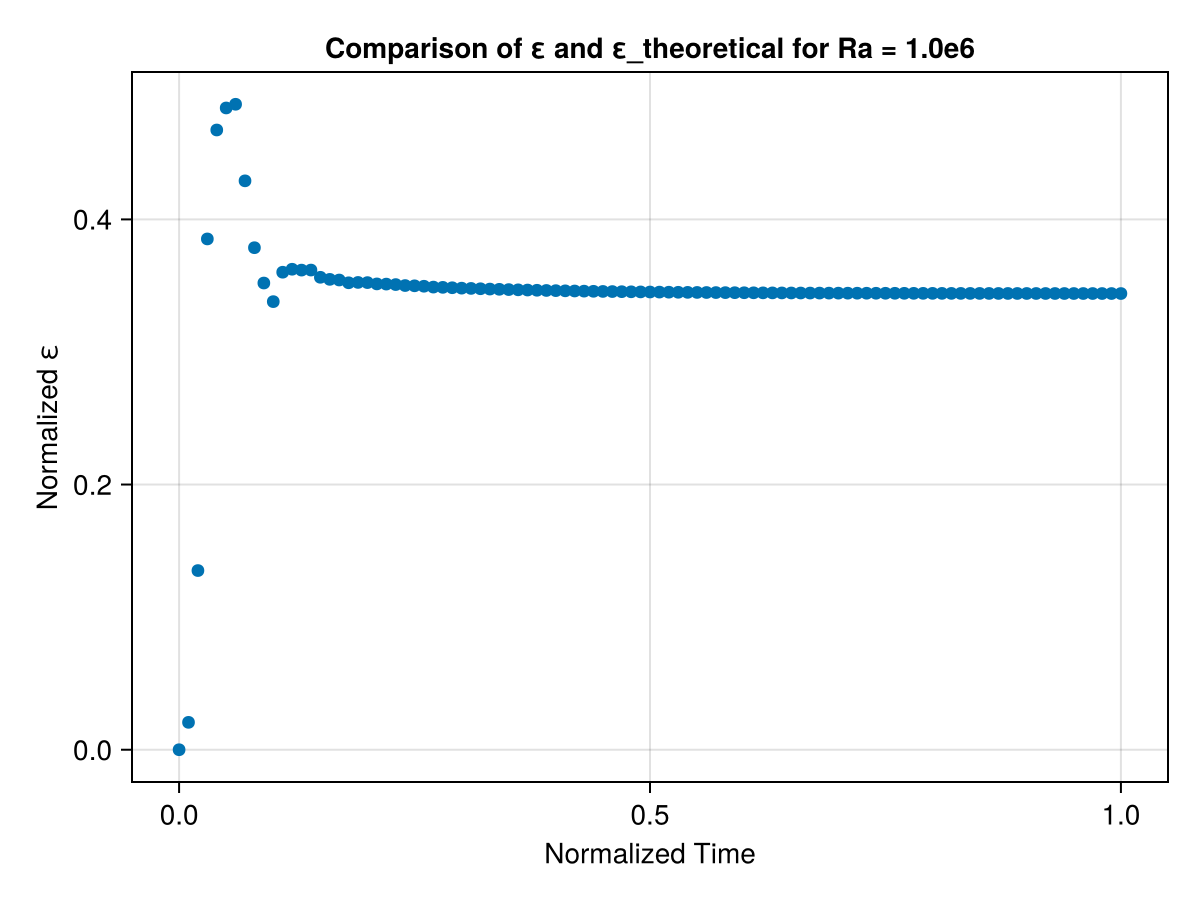

In [18]:
ε_theory_h1, ε_avg_h1, ε_mean_h1 = ε_analysis(ds_h1_o);
f_h1 = plot_ε_normalized(ds_h1_o)

f_h1

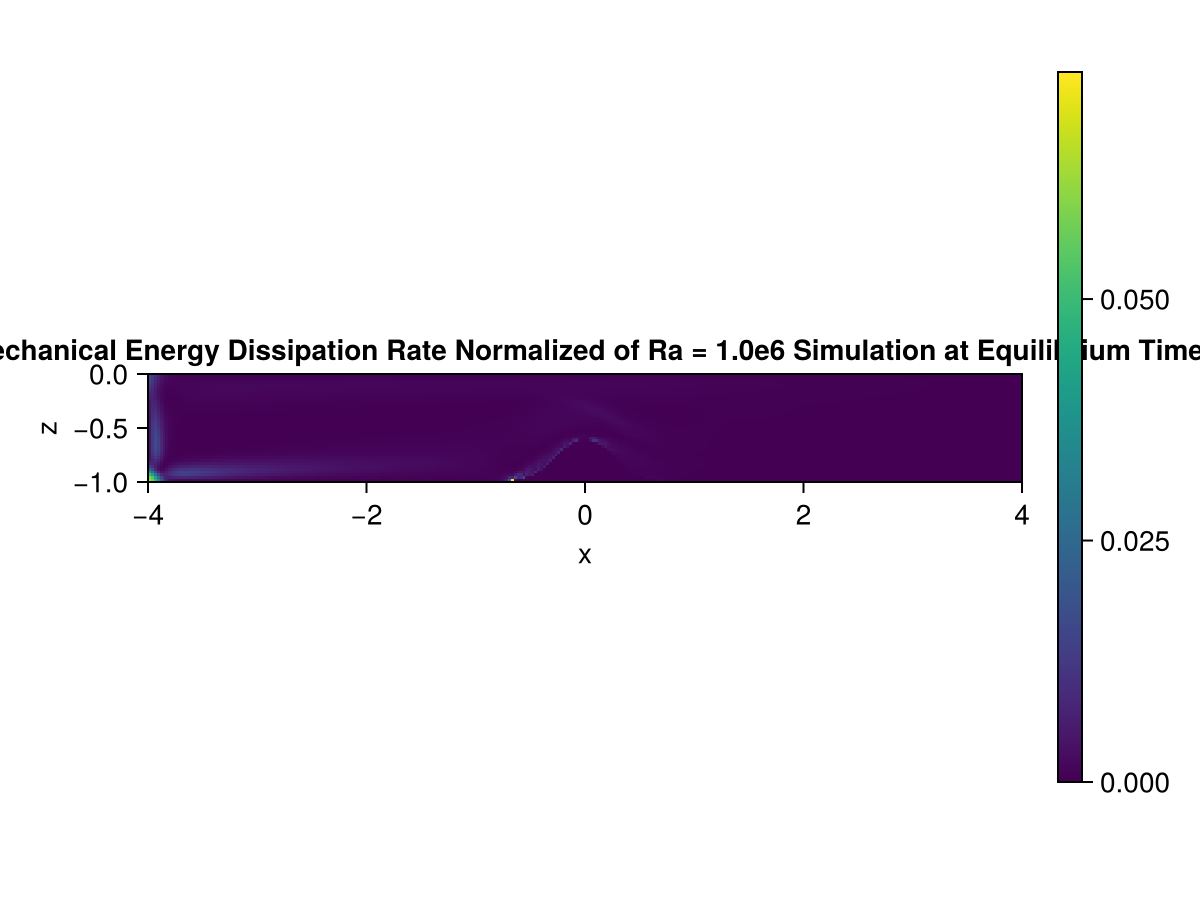

In [65]:
fig5 = plot_ε_equilibrium(ds_h1_o)

In [10]:
#Ra 5e6 one hill 

ds_h2_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_buoyancy.nc"));
ds_h2_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_oceanostics.nc"));


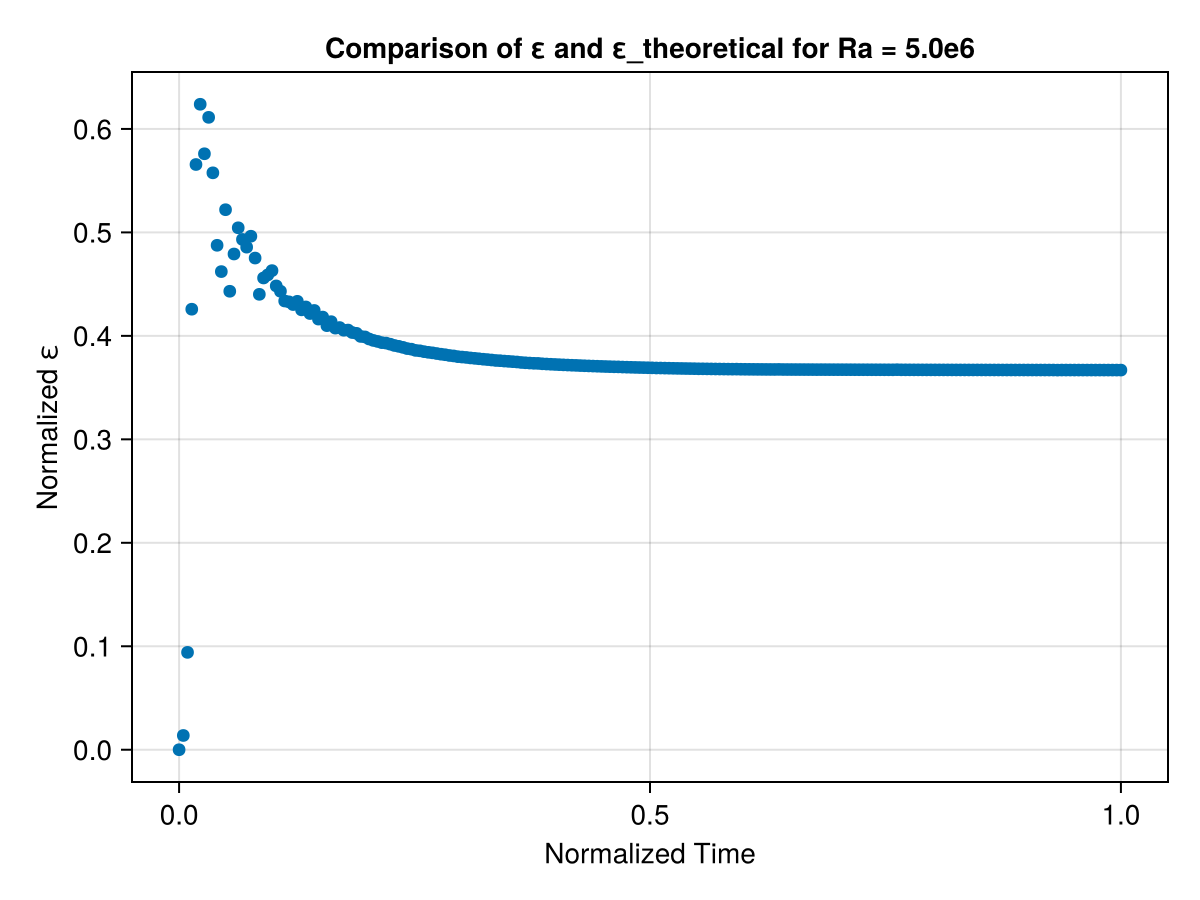

In [108]:
ε_theory_h2, ε_avg_h2, ε_mean_h2 = ε_analysis(ds_h2_o);
f_h2 = plot_ε_normalized(ds_h2_o);

Rayleigh number 1e7 with one hill

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill1e7.mp4" type "video/mp4">
</video>

In [11]:
#Ra 1e7 one hill

ds_h3_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_buoyancy.nc"));
ds_h3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_oceanostics.nc"));

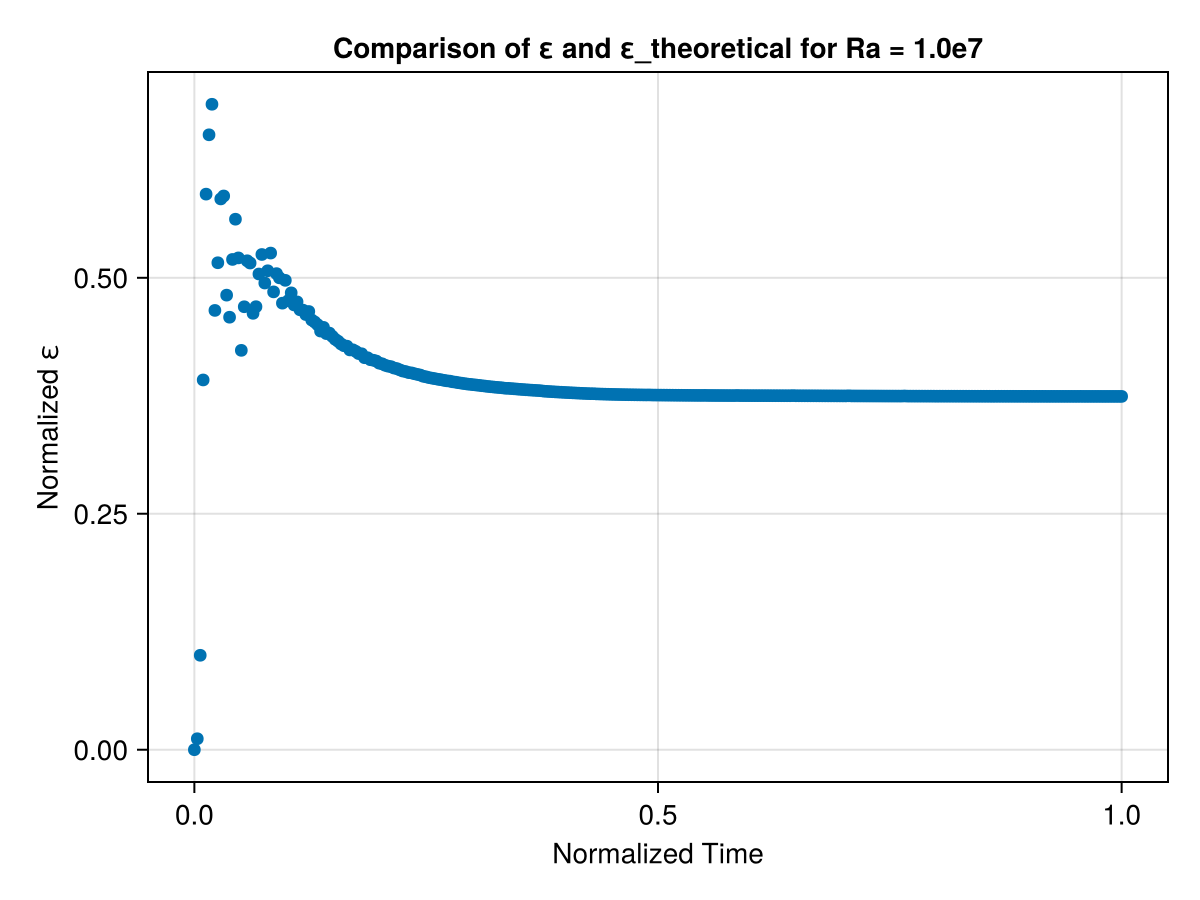

In [110]:
ε_theory_h3, ε_avg_h3, ε_mean_h3 = ε_analysis(ds_h3_o);
f_h3 = plot_ε_normalized(ds_h3_o)

In [107]:
b = ds_h3_b["b"][4+1:end-4, :, 4+1:end-4, :];
time = ds_h3_b["time"][:];

okay, time to make a joint plot of normalized epsilon vs time for all RA

lets start with no hills

In [51]:
#import the data here so I dont have to run all the turbulent_convection_hills_section_snapshots

ds0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra100000.0_coldstart_oceanostics.nc"));
ds1_o = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_oceanostics.nc"));
ds2_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra5.0e6_coldstart_oceanostics.nc"));
ds3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra1.0e7_coldstart_oceanostics.nc"));

list_of_datasets = [ds0_o, ds1_o, ds2_o, ds3_o]


#hills

ds_h0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_oceanostics.nc"));
ds_h1_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_oceanostics.nc"));
ds_h2_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_oceanostics.nc"));
ds_h3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_oceanostics.nc"));

list_hill_datasets = [ds_h0_o, ds_h1_o, ds_h2_o, ds_h3_o];

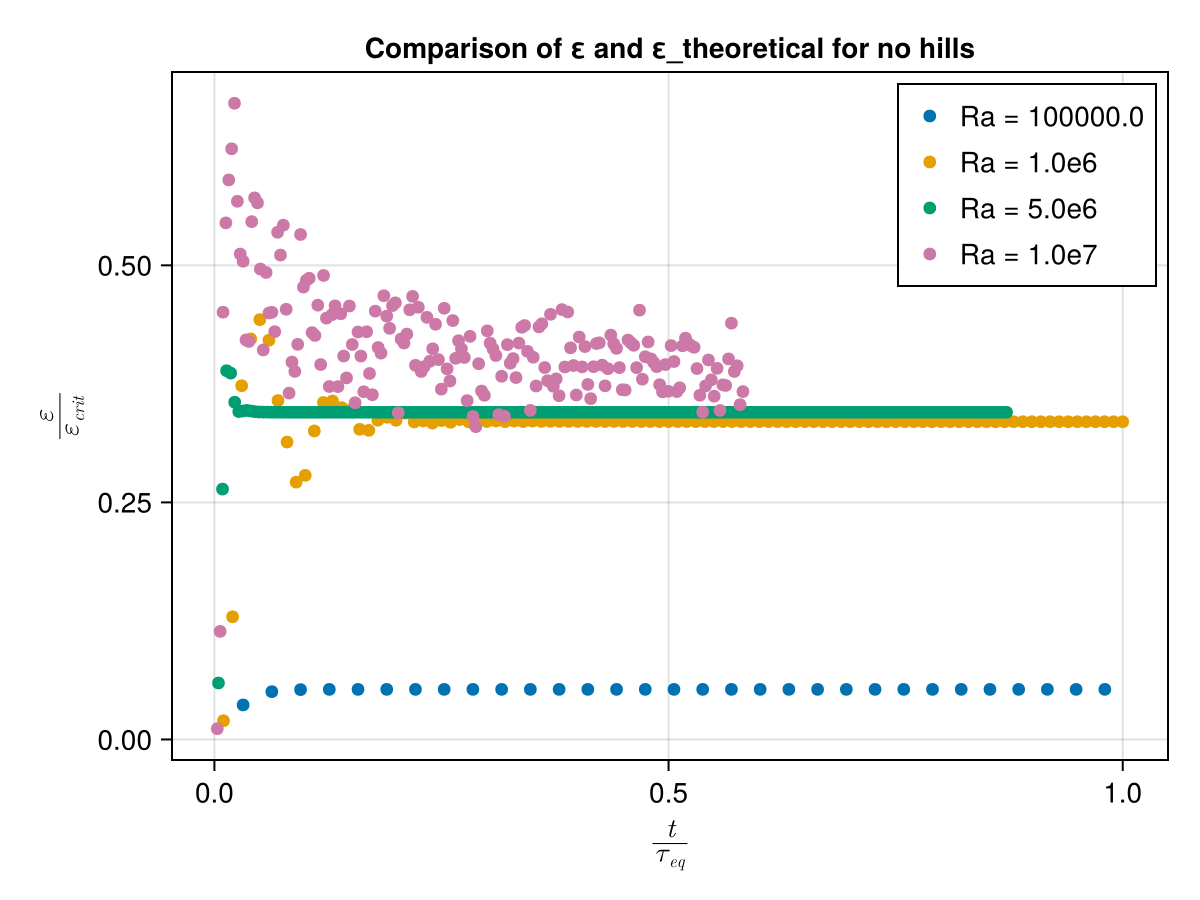

In [4]:
f = Figure()
ax = Axis(f[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"\frac{ε}{ε_{crit}}", title="Comparison of ε and ε_theoretical for no hills")
for ds in list_of_datasets
    plot_ε_normalized(ax, ds)
end

axislegend(ax)
f

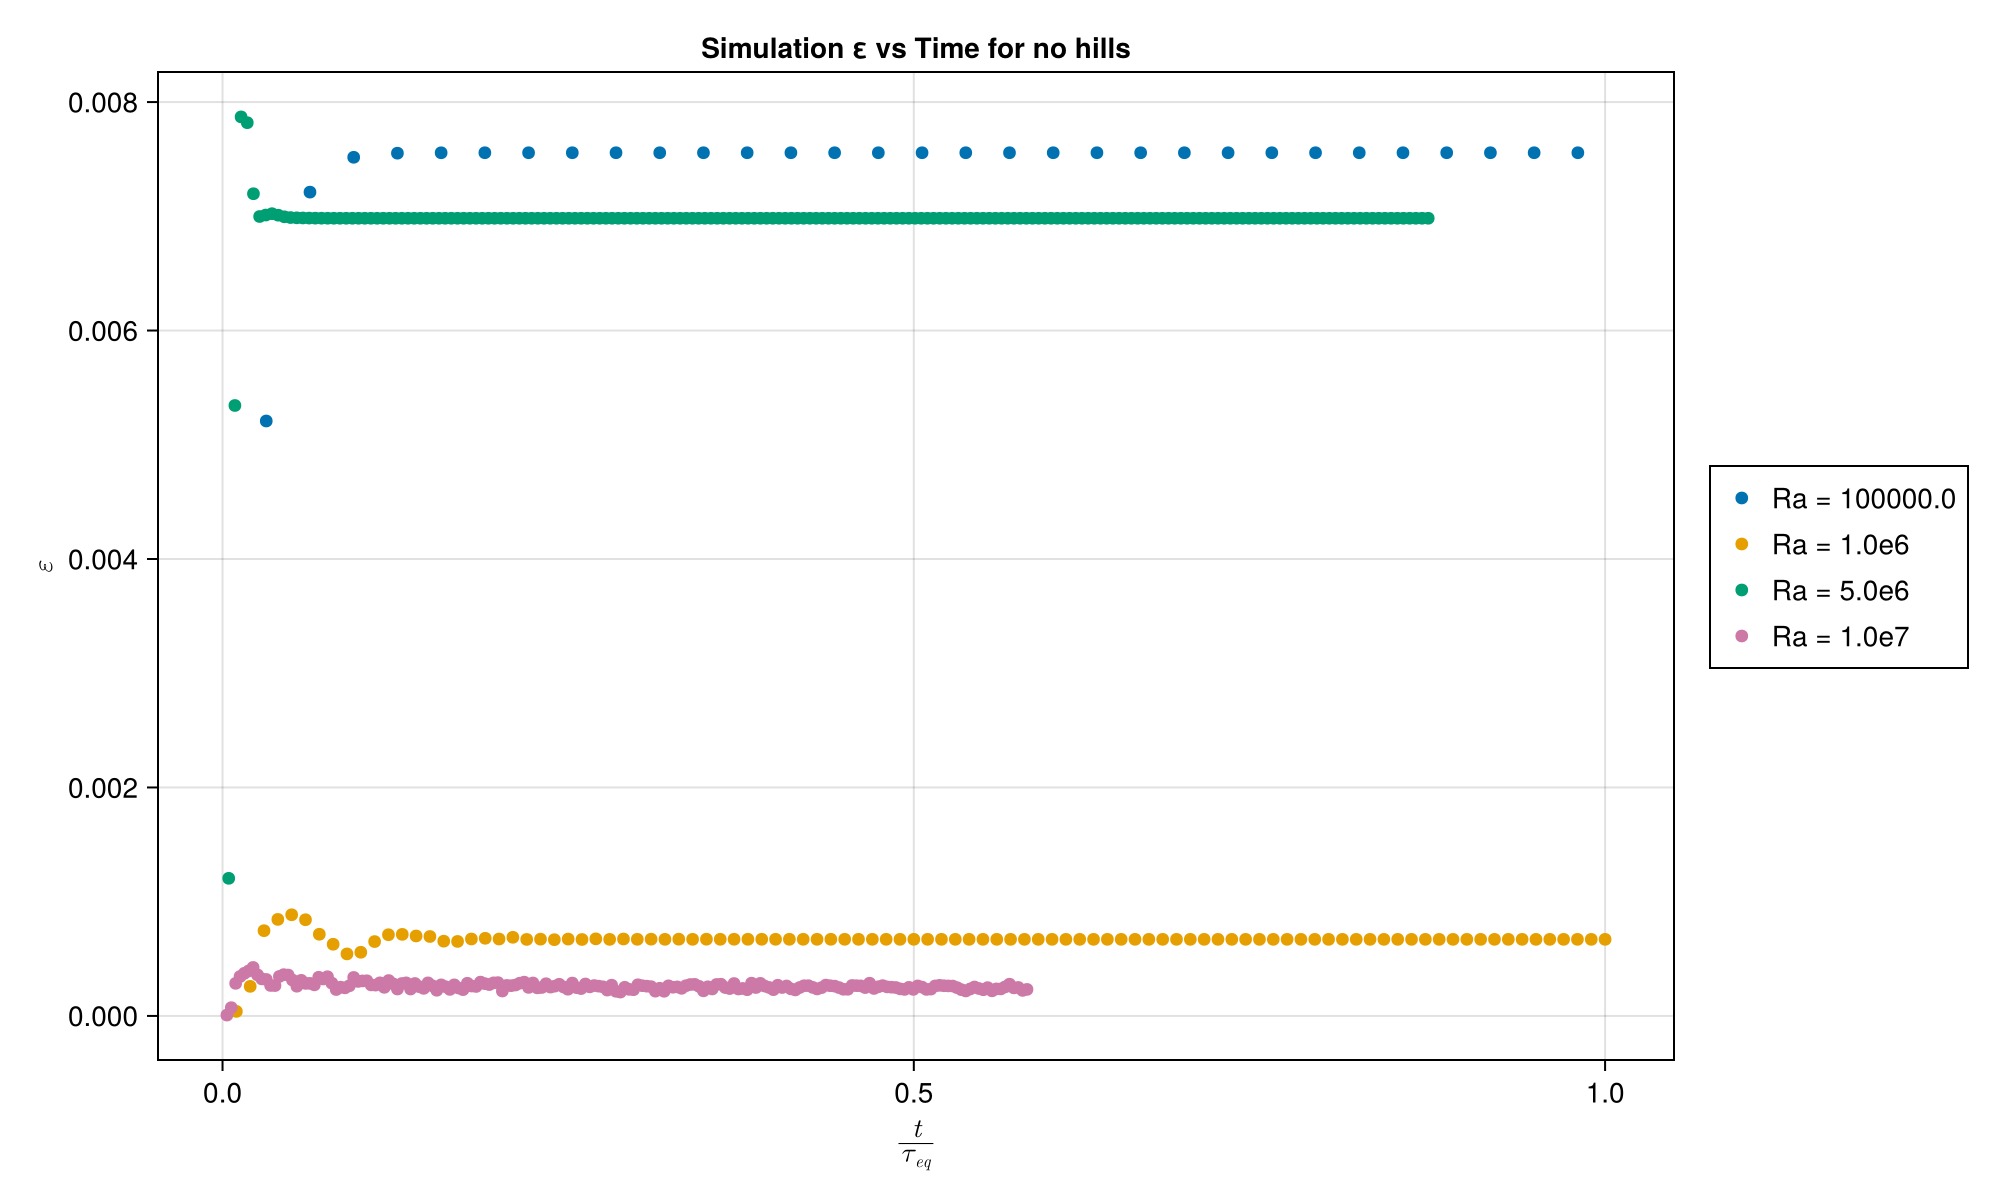

In [22]:
f1 = Figure(size=(1000, 600))
ax1 = Axis(f1[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"\varepsilon", title="Simulation ε vs Time for no hills")
for ds in list_of_datasets
    plot_ε_avg(ax1, ds)
end
Legend(f1[1, 2], ax1)  # Place legend in separate column
f1

Next, we want to make a scatter plot for the mean $\varepsilon$ averaged over the equilibrium period versus the Rayleigh number.

We also want to add theoretical $\varepsilon$ prediction curve to this plot. 

Recall : $\varepsilon_{crit} = 2 \kappa b_{\bigstar} H^{-1} $

We want $\varepsilon_{crit} $ as a function of the Rayleigh number, $Ra$. and Rayleigh number: $Ra = \frac{b_{\bigstar} H^3}{\nu \kappa}$

therefore, $\kappa = \frac{b_{\bigstar}H^3}{\nu Ra} $ and $\nu = \sqrt{\frac{Pr b_{\bigstar} H^3 } {Ra}}$ and $Pr = \frac{\nu}{\kappa}$ where Pr = 1

$b_{\bigstar} = H = 1 $ and $Pr = 1 $ , therefore $\nu = \kappa = \frac{1}{\sqrt{Ra}} $

and $\varepsilon_{crit} = \frac{2}{\sqrt{Ra}} $

Number of datasets: 4
Ra is: 1.000000e+05, b★ is: 1.000000, ν is: 7.155418e-02, H is: 1.000000

Ra is: 1.000000e+05, b★ is: 1.000000, ν is: 7.155418e-02, H is: 1.000000
Ra is: 1.000000e+06, b★ is: 1.000000, ν is: 1.000000e-03, H is: 1.000000
Ra is: 5.000000e+06, b★ is: 1.000000, ν is: 1.011929e-02, H is: 1.000000
Ra is: 1.000000e+07, b★ is: 1.000000, ν is: 3.162278e-04, H is: 1.000000
Ra is: 1.000000e+06, b★ is: 1.000000, ν is: 1.000000e-03, H is: 1.000000
Ra is: 5.000000e+06, b★ is: 1.000000, ν is: 1.011929e-02, H is: 1.000000
Ra is: 1.000000e+07, b★ is: 1.000000, ν is: 3.162278e-04, H is: 1.000000


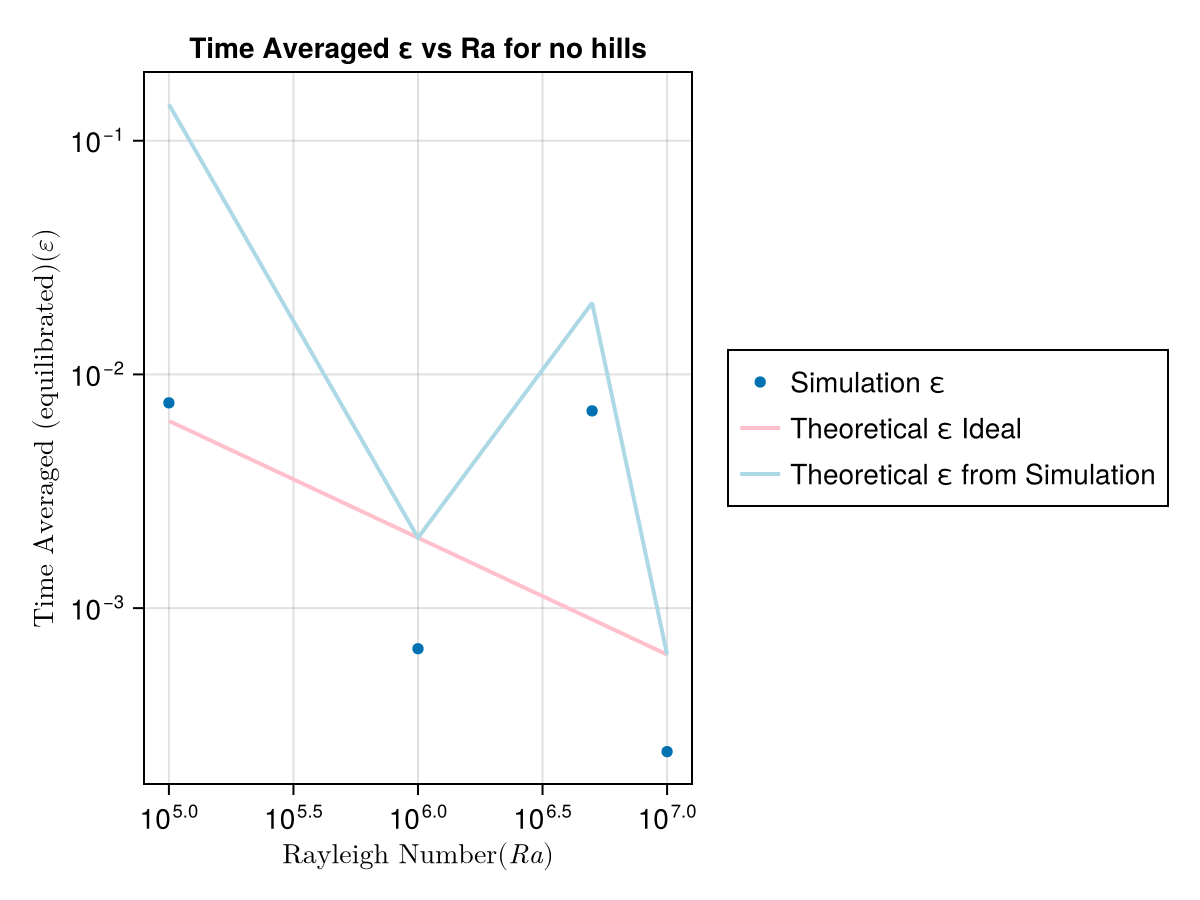

In [63]:
f_ε_scatter = Figure()
ax_ε_scatter = Axis(f_ε_scatter[1,1],
    xscale = log10,
    yscale = log10,
    xlabel=L"\text{Rayleigh Number} (Ra)",
    ylabel = L"\text{Time Averaged (equilibrated)} (ε)",
    title = "Time Averaged ε vs Ra for no hills")

Ra_vals = Float64[]
ε_means = Float64[]
ε_theories_from_sim = Float64[]
ε_theories_from_brain = Float64[]

println("Number of datasets: ", length(list_of_datasets))
for ds in list_of_datasets
    ε_mean = ε_analysis(ds)[3]
    ε_theory = ε_analysis(ds)[1]
    Ra = ds.attrib["Ra"]
    b★ = ds.attrib["b★"]
    ν = ds.attrib["ν"]
    H = ds.attrib["H"]
    @printf("Ra is: %e, b★ is: %f, ν is: %e, H is: %f\n", Ra, b★, ν, H)

    push!(Ra_vals, Ra)
    push!(ε_means, ε_mean)
    push!(ε_theories_from_brain, 2 / sqrt(Ra))
    push!(ε_theories_from_sim, ε_theory)
end

#plot the scatter points
scatter!(ax_ε_scatter, Ra_vals, ε_means, label="Simulation ε", markersize=8)

#plot the theoretical ε curve
lines!(ax_ε_scatter, Ra_vals, ε_theories_from_brain, label="Theoretical ε Ideal", color=:pink, linewidth=2)
lines!(ax_ε_scatter, Ra_vals, ε_theories_from_sim, label="Theoretical ε from Simulation", color=:lightblue, linewidth=2)

Legend(f_ε_scatter[1,2], ax_ε_scatter)  # Add the legend
f_ε_scatter

okay, so the pink theoretical $\varepsilon$ curve comes from the algebraic manipulation of the definitions, plugging in the simulation parameters that remain constant ($H, b_{\bigstar}, \text{and } Pr$), and solving as a function of rayleigh number. This gave us $\varepsilon = \frac{2}{\sqrt{Ra}}$

the blue theoretical $\varepsilon$ curve comes from the plugging in the global attributes of the simulation directly into the theoretical definition of $\varepsilon = 2 \kappa b_{\bigstar} H^{-1} $

It's clear from the figure above that something went wrong with the $Ra = 1e5$ and $Ra = 5e6$ simulations. 

In [58]:
println(Ra_vals)
println(ε_means)
println(ε_theories)

[100000.0, 1.0e6, 5.0e6, 1.0e7]
[0.007556579026952185, 0.0006701613638236988, 0.006982914448636357, 0.00024311562110557473]
[0.14310835055998655, 0.002, 0.020238577025077628, 0.0006324555320336759]


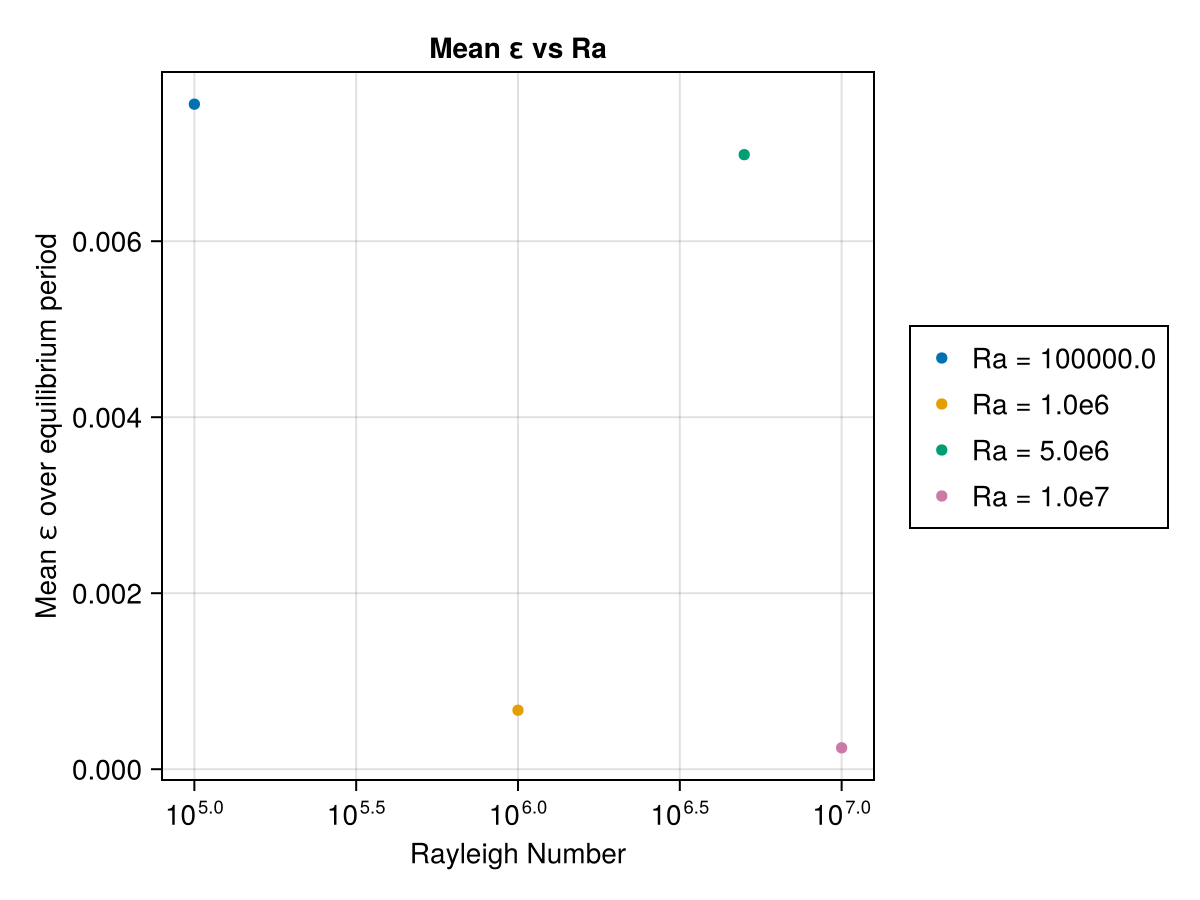

In [ ]:
f_ε_scatter = Figure()
ax_ε_scatter = Axis(f_ε_scatter[1, 1], xscale = log10, xlabel="Rayleigh Number", ylabel="Mean ε over equilibrium period", title="Mean ε vs Ra")

for ds in list_of_datasets
    ε_mean = ε_analysis(ds)[3]
    Ra = ds.attrib["Ra"]
    b★ = ds.attrib["b★"]
    ν = ds.attrib["ν"]
    H = ds.attrib["H"]
    
    scatter!(ax_ε_scatter, Ra, ε_mean, label=string("Ra = ", Ra), markersize=8)
end
Legend(f_ε_scatter[1,2], ax_ε_scatter)  # Add the legend
f_ε_scatter




<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill5e6.mp4" type "video/mp4">
</video>

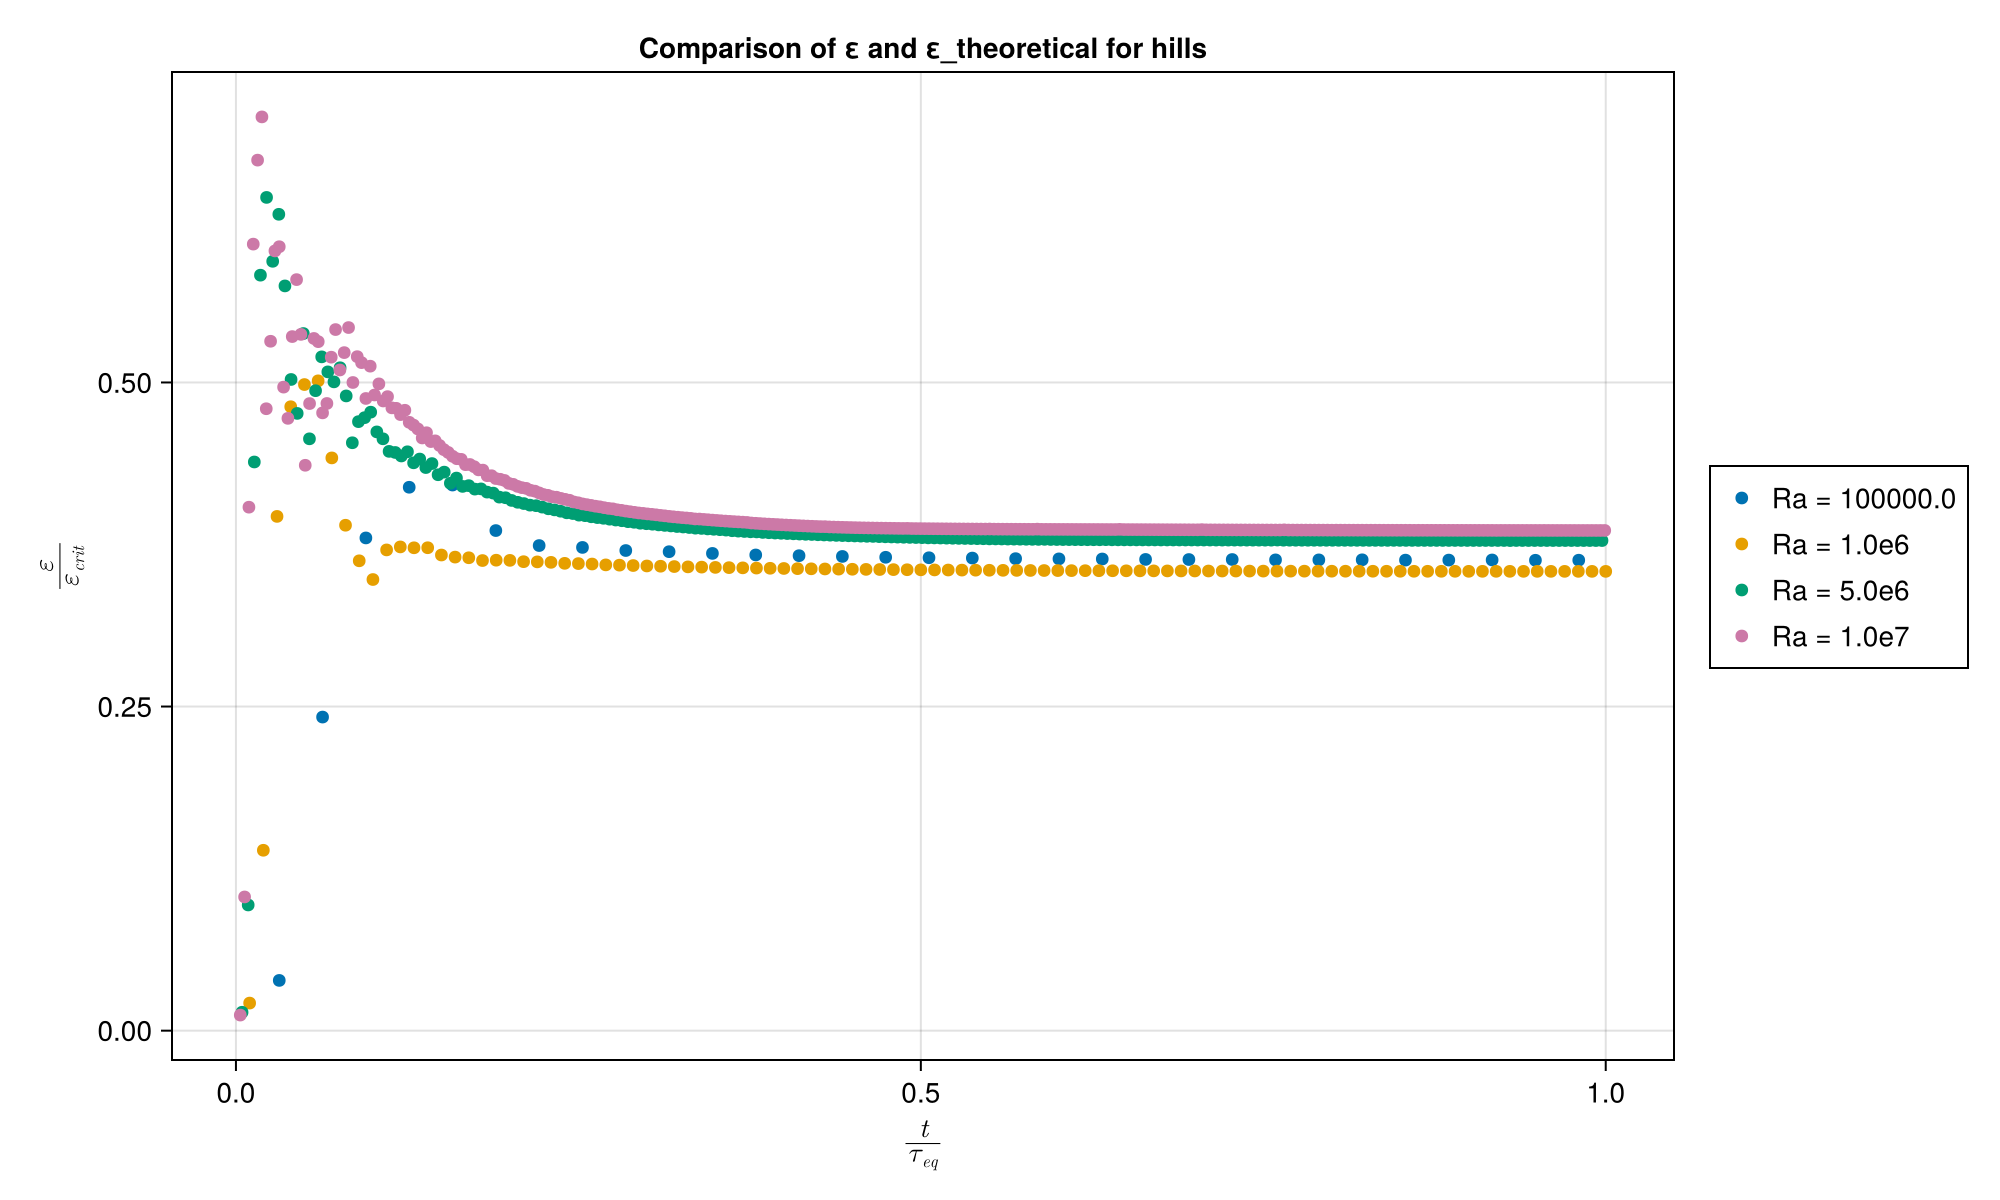

In [23]:
list_hill_datasets = [ds_h0_o,ds_h1_o, ds_h2_o, ds_h3_o]
f_hills = Figure(size=(1000, 600))
ax_hills = Axis(f_hills[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"\frac{ε}{ε_{crit}}", title="Comparison of ε and ε_theoretical for hills")
for ds in list_hill_datasets
    plot_ε_normalized(ax_hills, ds)
end

Legend(f_hills[1, 2], ax_hills)
f_hills

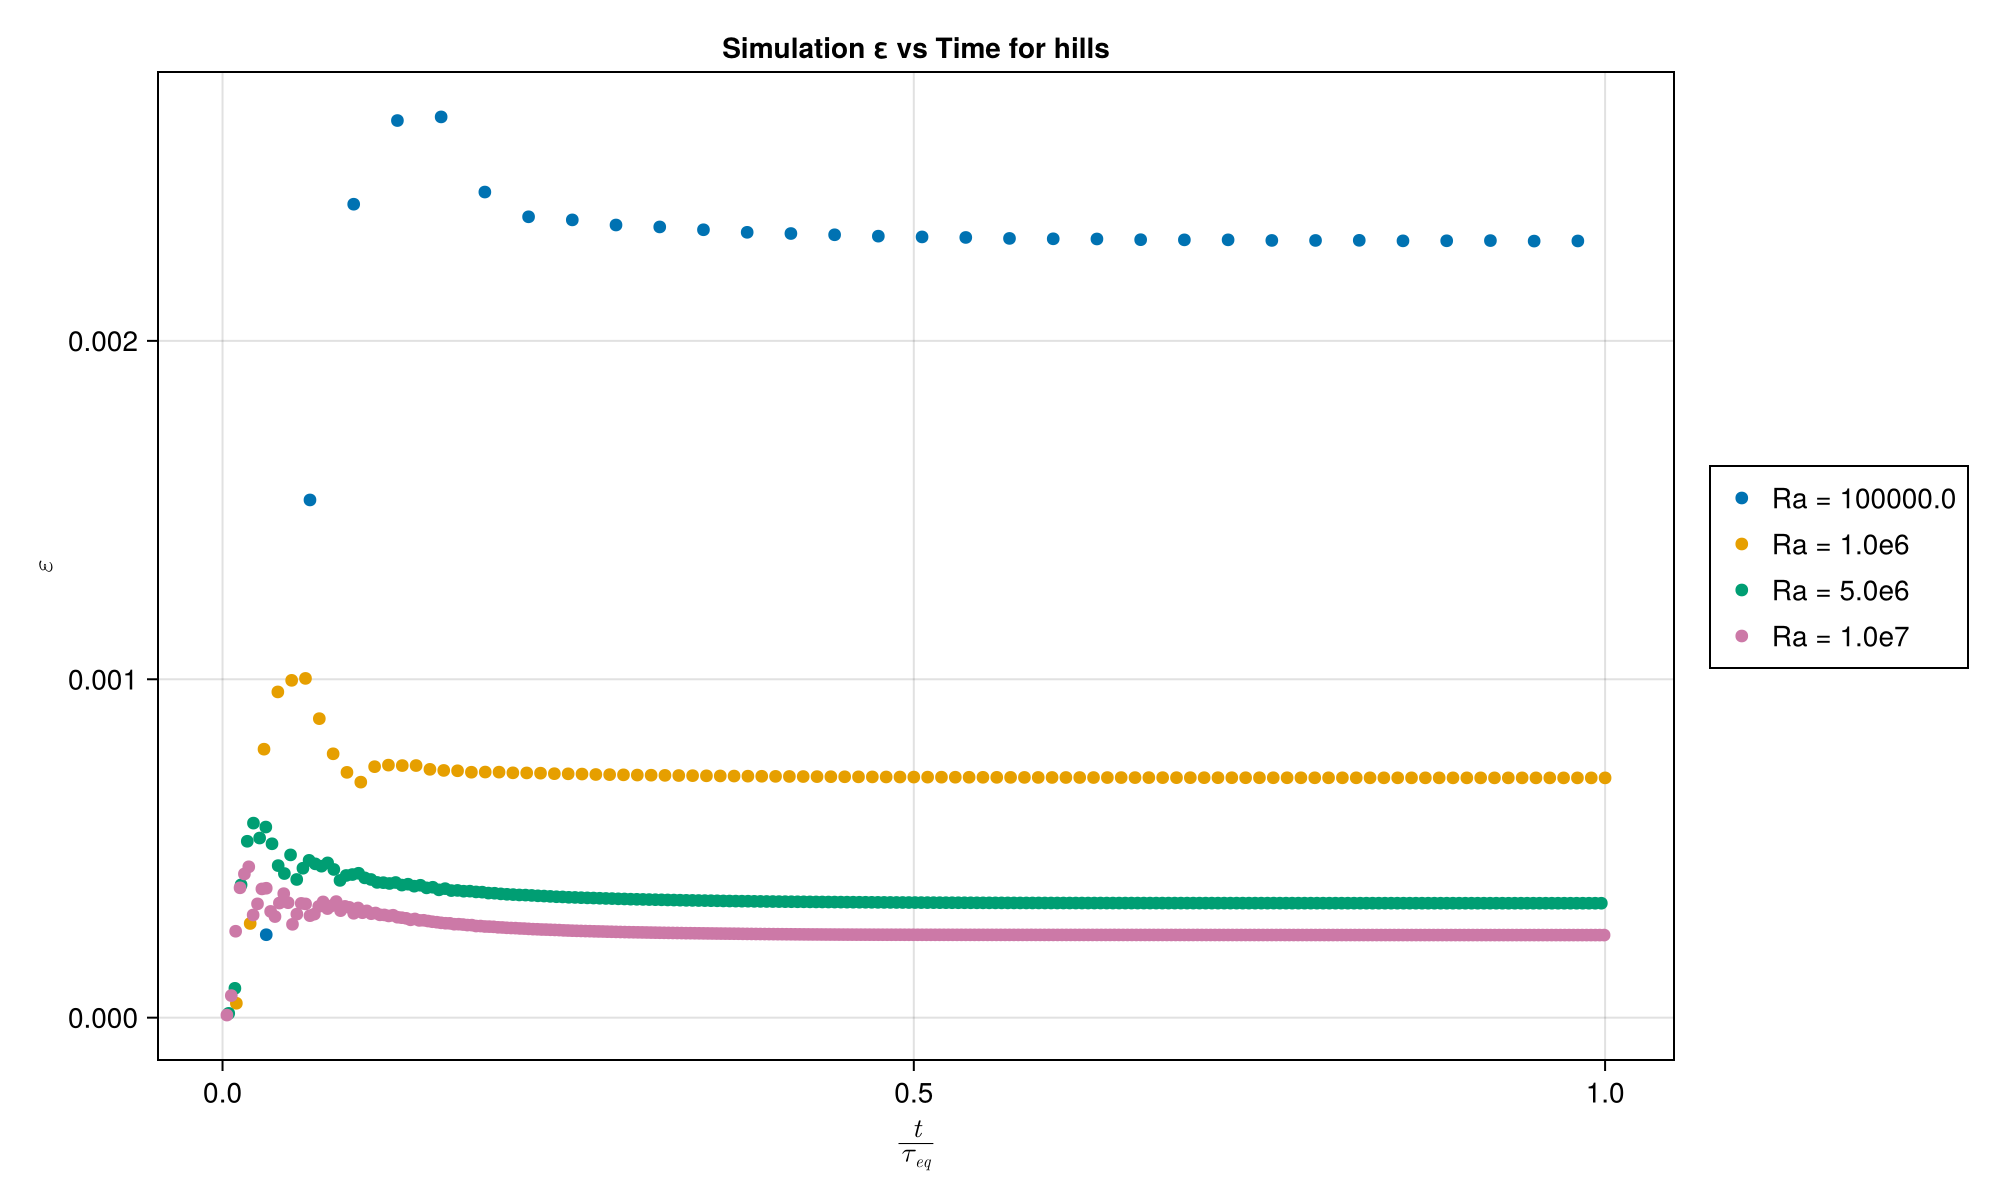

In [24]:
f_hills_2 = Figure(size=(1000, 600))
ax_hills_2 = Axis(f_hills_2[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"\varepsilon", title="Simulation ε vs Time for hills")
for ds in list_hill_datasets
    plot_ε_avg(ax_hills_2, ds)
end
Legend(f_hills_2[1, 2], ax_hills_2)
f_hills_2

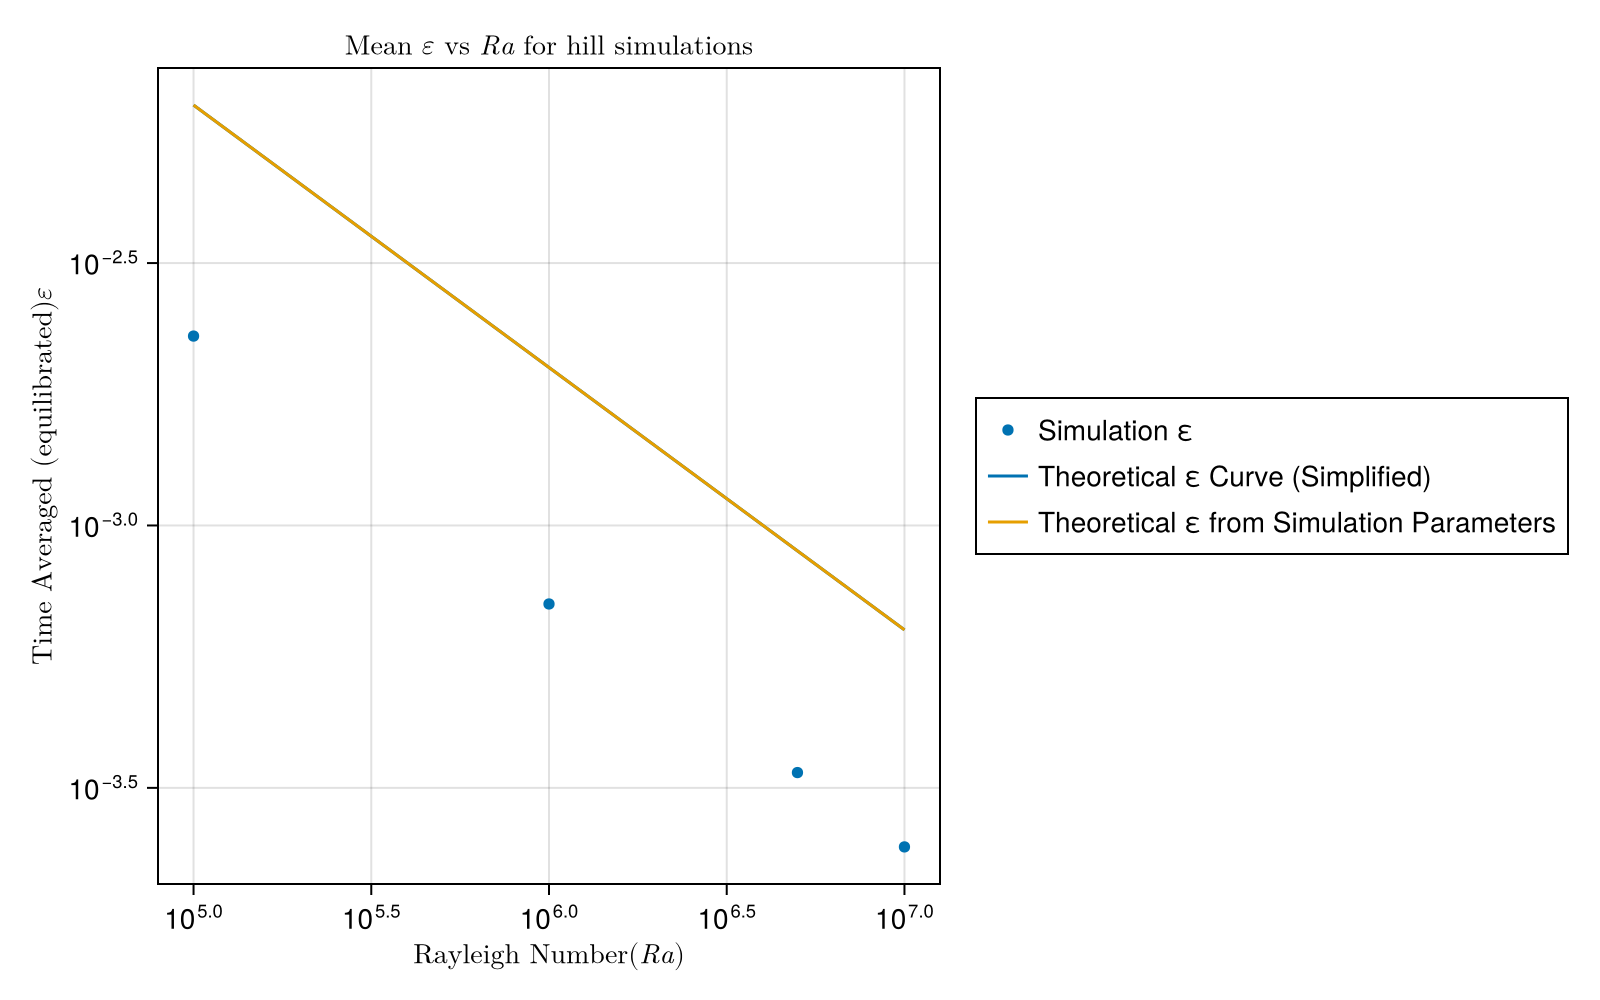

In [75]:
f_ε_scatter_hill = Figure(size = (800, 500))
ax_ε_scatter_hill = Axis(f_ε_scatter_hill[1, 1], 
    xscale = log10, 
    yscale = log10,
    xlabel=L"\text{Rayleigh Number} (Ra)", 
    ylabel=L"\text{Time Averaged (equilibrated)} \varepsilon", 
    title=L"\text{Mean } \varepsilon \text{ vs } Ra \text{ for hill simulations}")

Ra_vals = Float64[]
ε_means_hill = Float64[]
ε_theories_from_sim_hill = Float64[]
ε_theories_from_brain_hill = Float64[]

for ds in list_hill_datasets
    ε_mean = ε_analysis(ds)[3]
    ε_sim_theory = ε_analysis(ds)[1]
    Ra = ds.attrib["Ra"]

    push!(Ra_vals, Ra)
    push!(ε_means_hill, ε_mean)
    push!(ε_theories_from_brain_hill, 2 / sqrt(Ra))
    push!(ε_theories_from_sim_hill, ε_sim_theory)
end


#plot the scatter points
scatter!(ax_ε_scatter_hill, Ra_vals, ε_means_hill, label="Simulation ε", markersize=8)
#theoretical prediction curve
lines!(ax_ε_scatter_hill, Ra_vals, ε_theories_from_brain_hill, label="Theoretical ε Curve (Simplified)")
lines!(ax_ε_scatter_hill, Ra_vals, ε_theories_from_sim_hill, label = "Theoretical ε from Simulation Parameters")

Legend(f_ε_scatter_hill[1, 2], ax_ε_scatter_hill)
f_ε_scatter_hill

